# Credit Default Risk Modelling
### Home Credit Default Risk 

---

## Executive Summary

**Business Problem:** Home Credit serves borrowers with limited or no formal credit history. The core risk is twofold: extending loans to applicants who will default generates direct credit losses, while rejecting creditworthy applicants generates opportunity cost. This notebook builds a production-grade default prediction model that explicitly quantifies and balances these two error types.

**Approach:** Multi-table feature engineering across four data sources (loan applications, Credit Bureau history, previous Home Credit loans, and instalment payment behaviour), trained on XGBoost with SHAP-based explainability and business-driven threshold optimisation.

**Modelling Decisions:**
- SMOTE applied only to training data — never to validation or test sets
- Threshold tuned on validation set using a cost-sensitive framework, not accuracy
- GridSearchCV scored on `roc_auc` — the industry standard for credit risk
- SHAP values ensure every prediction is auditable — critical for Basel III and POPIA compliance
- Multi-table joins capture behavioural signals unavailable in the application form alone

---

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
print('Libraries loaded ✓')

Libraries loaded ✓


C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading application_train...


UFuncTypeError: ufunc 'less' did not contain a loop with signature matching types (<class 'numpy.dtypes.Float16DType'>, <class 'numpy.dtypes.StrDType'>) -> None

---
## 1. Business Problem Framing

### 1.1 Credit Risk in Context

In credit risk modelling, the standard expected loss framework decomposes risk into three components:

$$\text{Expected Loss} = PD \times LGD \times EAD$$

Where:
- **PD** — Probability of Default (what our model estimates)
- **LGD** — Loss Given Default (how much is lost if default occurs; typically 40–70% for unsecured loans)
- **EAD** — Exposure at Default (outstanding loan balance at time of default)

### 1.2 The Two Error Types

| Error | Technical Name | Business Impact |
|---|---|---|
| Predict Repaid, Actually Defaults | **False Negative** | Loan issued → default → credit loss hits P&L |
| Predict Default, Actually Repays | **False Positive** | Loan rejected → lost interest income, reputational risk |

For a bank, **False Negatives are typically 3–6× more costly** than False Positives:
- Credit losses are direct P&L hits and consume regulatory capital
- Rejected good applicants simply go to a competitor — opportunity cost only

This asymmetry drives our threshold optimisation in Section 6.

### 1.3 Target Variable
- `TARGET = 1` → Client defaulted or had serious payment delinquency (60+ days overdue)
- `TARGET = 0` → Client repaid successfully

---
## 2. Data Loading

In [2]:
# ── Update DATA_PATH to your folder ──────────────────────────────────────
DATA_PATH = './'

print('Loading tables...')
app    = pd.read_csv('application_train.csv')
bureau = pd.read_csv('bureau.csv')
prev   = pd.read_csv('previous_application.csv')
inst   = pd.read_csv('installments_payments.csv')

print(f'application_train : {app.shape[0]:,} rows x {app.shape[1]} cols')
print(f'bureau            : {bureau.shape[0]:,} rows x {bureau.shape[1]} cols')
print(f'previous_app      : {prev.shape[0]:,} rows x {prev.shape[1]} cols')
print(f'installments      : {inst.shape[0]:,} rows x {inst.shape[1]} cols')
print('\nAll tables loaded ✓')

Loading tables...
application_train : 307,511 rows x 122 cols
bureau            : 1,716,428 rows x 17 cols
previous_app      : 1,670,214 rows x 37 cols
installments      : 13,605,401 rows x 8 cols

All tables loaded ✓


In [4]:
app.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,...,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,...,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,...,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,100006,0,Cash loans,F,N,Y,0,135000.0000,312682.5000,29686.5000,297000.0000,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.0080,-19005,-3039,-9833.0000,-2437,NaN,1,1,0,1,0,0,Laborers,2.0000,2,2,WEDNESDAY,17,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0000,0.0000,2.0000,0.0000,-617.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0000,513000.0000,21865.5000,513000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0287,-19932,-3038,-4311.0000,-3458,NaN,1,1,0,1,0,0,Core staff,1.0000,2,2,THURSDAY,11,0,0,0,0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-1106.0000,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [5]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0000,-153.0000,NaN,0,91323.0000,0.0000,NaN,0.0000,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0000,NaN,NaN,0,225000.0000,171342.0000,NaN,0.0000,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0000,NaN,NaN,0,464323.5000,NaN,NaN,0.0000,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0000,NaN,NaN,0.0000,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0000,NaN,77674.5000,0,2700000.0000,NaN,NaN,0.0000,Consumer credit,-21,NaN


In [6]:
prev.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.4300,17145.0000,17145.0000,0.0000,17145.0000,SATURDAY,15,Y,1,0.0000,0.1828,0.8673,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0000,middle,POS mobile with interest,365243.0000,-42.0000,300.0000,-42.0000,-37.0000,0.0000
1,2802425,108129,Cash loans,25188.6150,607500.0000,679671.0000,NaN,607500.0000,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0000,low_action,Cash X-Sell: low,365243.0000,-134.0000,916.0000,365243.0000,365243.0000,1.0000
2,2523466,122040,Cash loans,15060.7350,112500.0000,136444.5000,NaN,112500.0000,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0000,high,Cash X-Sell: high,365243.0000,-271.0000,59.0000,365243.0000,365243.0000,1.0000
3,2819243,176158,Cash loans,47041.3350,450000.0000,470790.0000,NaN,450000.0000,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0000,middle,Cash X-Sell: middle,365243.0000,-482.0000,-152.0000,-182.0000,-177.0000,1.0000
4,1784265,202054,Cash loans,31924.3950,337500.0000,404055.0000,NaN,337500.0000,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0000,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
inst.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0000,6,-1180.0000,-1187.0000,6948.3600,6948.3600
1,1330831,151639,0.0000,34,-2156.0000,-2156.0000,1716.5250,1716.5250
2,2085231,193053,2.0000,1,-63.0000,-63.0000,25425.0000,25425.0000
3,2452527,199697,1.0000,3,-2418.0000,-2426.0000,24350.1300,24350.1300
4,2714724,167756,1.0000,2,-1383.0000,-1366.0000,2165.0400,2160.5850


---
## 3. Exploratory Data Analysis

### 3.1 Target Distribution

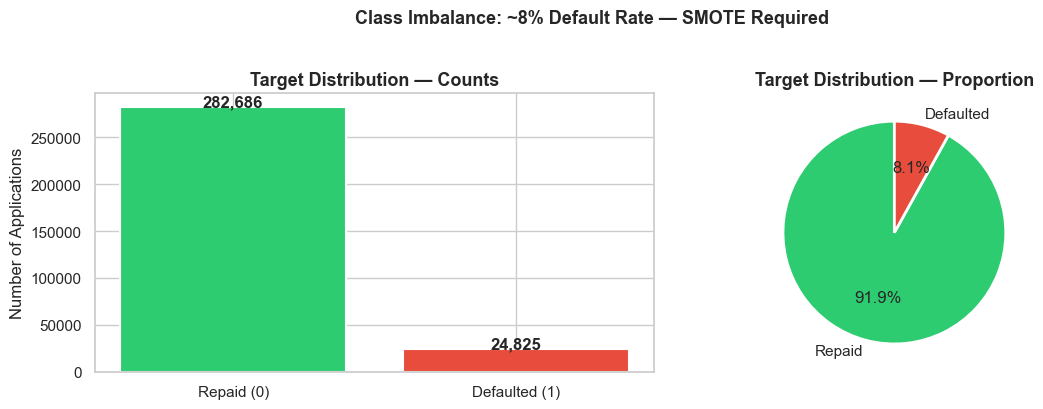

Default rate: 8.1%


In [8]:
target_counts = app['TARGET'].value_counts()
target_pct    = app['TARGET'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Repaid (0)', 'Defaulted (1)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Distribution — Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Applications')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(target_pct.values, labels=['Repaid', 'Defaulted'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Target Distribution — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance: ~8% Default Rate — SMOTE Required', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Default rate: {target_pct[1]:.1f}%')

### 3.2 Key Feature Distributions by Default Status

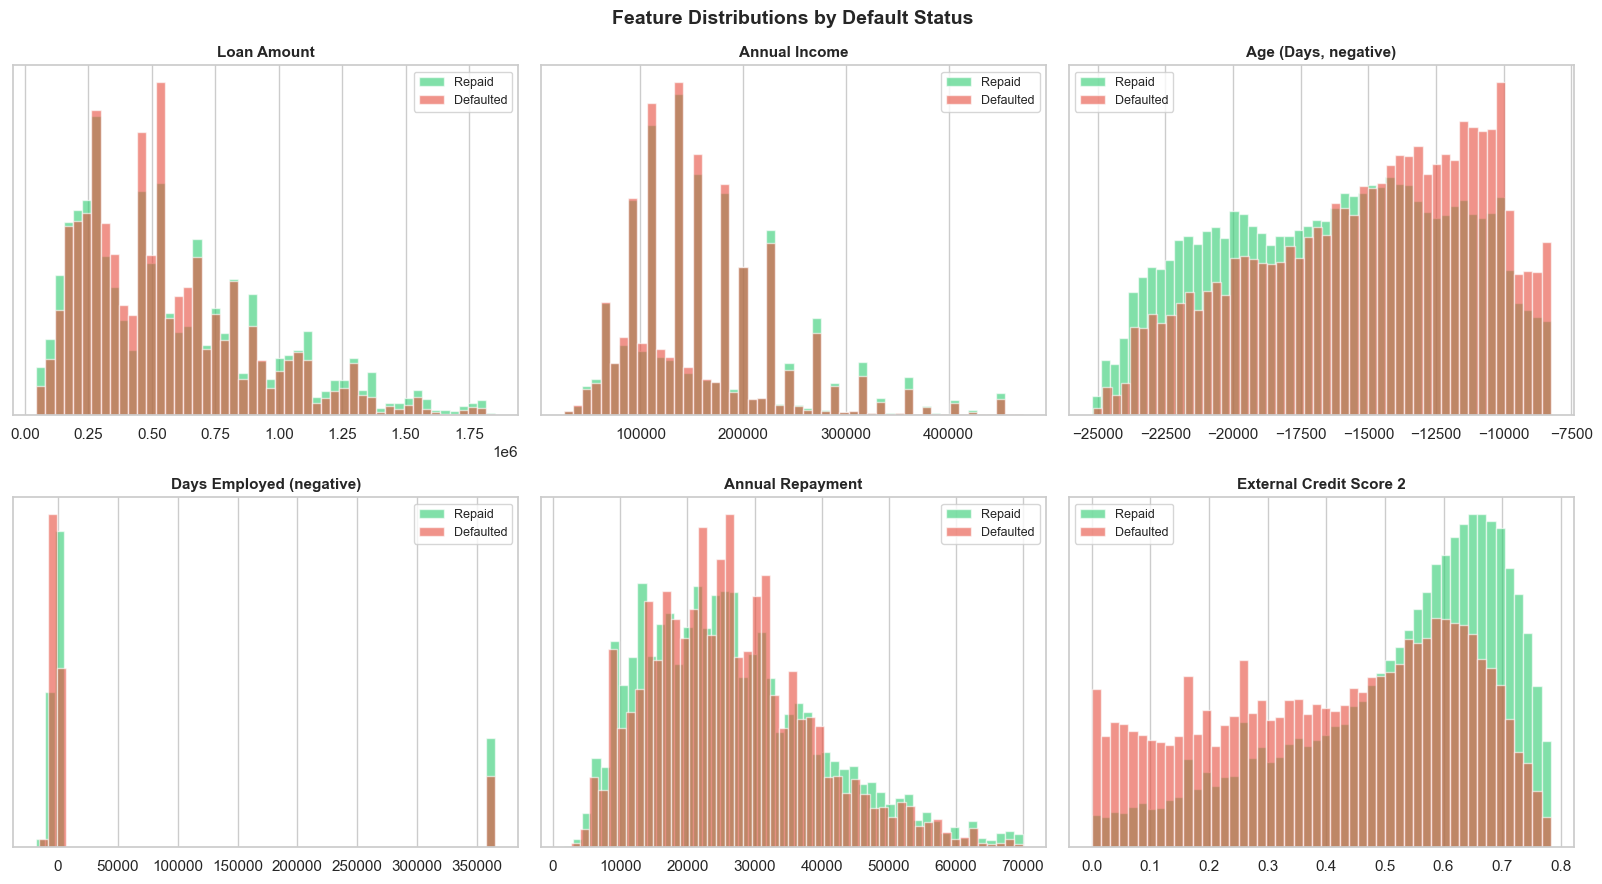

In [9]:
plot_features = [
    ('AMT_CREDIT',       'Loan Amount'),
    ('AMT_INCOME_TOTAL', 'Annual Income'),
    ('DAYS_BIRTH',       'Age (Days, negative)'),
    ('DAYS_EMPLOYED',    'Days Employed (negative)'),
    ('AMT_ANNUITY',      'Annual Repayment'),
    ('EXT_SOURCE_2',     'External Credit Score 2'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (col, label) in zip(axes.flatten(), plot_features):
    cap = app[col].quantile(0.99)
    for val, color, lbl in [(0,'#2ecc71','Repaid'),(1,'#e74c3c','Defaulted')]:
        d = app.loc[app['TARGET']==val, col].dropna()
        d = d[d <= cap]
        ax.hist(d, bins=50, alpha=0.6, color=color, label=lbl, density=True)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_yticks([])

plt.suptitle('Feature Distributions by Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 External Credit Scores — Strongest Signal

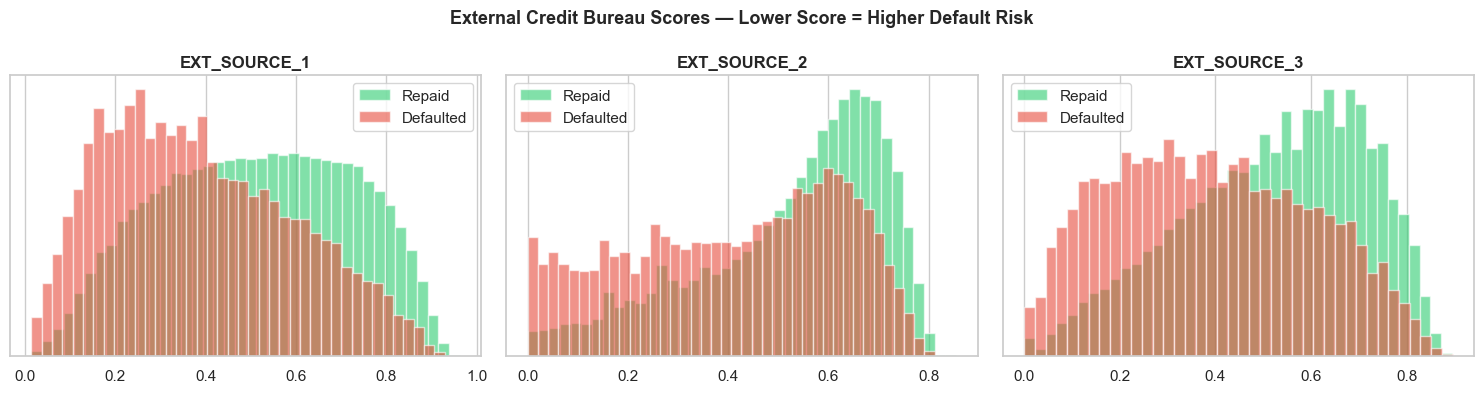

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    for val, color, lbl in [(0,'#2ecc71','Repaid'),(1,'#e74c3c','Defaulted')]:
        ax.hist(app.loc[app['TARGET']==val, col].dropna(),
                bins=40, alpha=0.6, color=color, label=lbl, density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend()
    ax.set_yticks([])

plt.suptitle('External Credit Bureau Scores — Lower Score = Higher Default Risk',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Missing Value Analysis

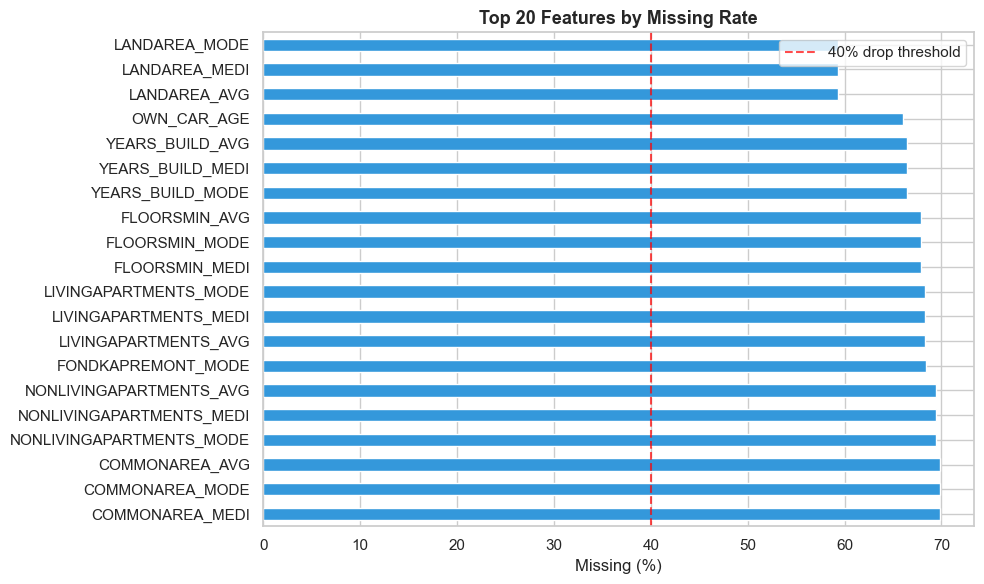

In [11]:
missing = (app.isnull().sum() / len(app) * 100)
missing = missing[missing > 0].sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
missing.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_xlabel('Missing (%)')
ax.set_title('Top 20 Features by Missing Rate', fontsize=13, fontweight='bold')
ax.axvline(40, color='red', linestyle='--', alpha=0.7, label='40% drop threshold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering

Every feature below is derived from **domain reasoning**, not blind transformation.

### 4.1 Application Table — Ratio Features

In [12]:
df = app.copy()

# Debt-to-income: higher = more stretched borrower
df['DEBT_TO_INCOME'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)

# Monthly repayment burden relative to income
df['ANNUITY_TO_INCOME'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)

# LTV proxy: how much of goods price is financed
df['CREDIT_TO_GOODS'] = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + 1)

# Age in years (DAYS_BIRTH is stored as negative)
df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365

# Employment length — 365243 is a sentinel for unemployed
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['EMPLOYED_YEARS'] = -df['DAYS_EMPLOYED'] / 365

# Employment stability: short tenure relative to age = higher risk
df['EMPLOYMENT_TO_AGE'] = df['EMPLOYED_YEARS'] / (df['AGE_YEARS'] + 1)

# Aggregate bureau score signal
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
df['EXT_SOURCE_MIN']  = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].min(axis=1)

# Income per family member
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)

print('Application features engineered ✓')

Application features engineered ✓


### 4.2 Bureau Table — External Credit History

> Number of active loans, overdue days, and total debt from the Credit Bureau are strong behavioural signals. We aggregate per applicant.

In [13]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT       = ('SK_ID_BUREAU',          'count'),
    BUREAU_ACTIVE_LOANS     = ('CREDIT_ACTIVE',         lambda x: (x=='Active').sum()),
    BUREAU_AMT_CREDIT_SUM   = ('AMT_CREDIT_SUM',        'sum'),
    BUREAU_AMT_CREDIT_DEBT  = ('AMT_CREDIT_SUM_DEBT',   'sum'),
    BUREAU_AMT_OVERDUE      = ('AMT_CREDIT_SUM_OVERDUE','sum'),
    BUREAU_MAX_OVERDUE_DAYS = ('CREDIT_DAY_OVERDUE',    'max'),
    BUREAU_AVG_OVERDUE_DAYS = ('CREDIT_DAY_OVERDUE',    'mean'),
    BUREAU_CLOSED_LOANS     = ('CREDIT_ACTIVE',         lambda x: (x=='Closed').sum()),
).reset_index()

# Debt utilisation ratio
bureau_agg['BUREAU_DEBT_RATIO'] = (
    bureau_agg['BUREAU_AMT_CREDIT_DEBT'] /
    (bureau_agg['BUREAU_AMT_CREDIT_SUM'] + 1)
)

df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
print(f'Bureau features merged ✓  |  Shape: {df.shape}')

Bureau features merged ✓  |  Shape: (307511, 140)


### 4.3 Previous Applications — Past Home Credit Behaviour

> Multiple previous rejections, or a pattern of cancelling approved loans, signals elevated risk.

In [14]:
prev_agg = prev.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT       = ('SK_ID_PREV',            'count'),
    PREV_APPROVED        = ('NAME_CONTRACT_STATUS',  lambda x: (x=='Approved').sum()),
    PREV_REFUSED         = ('NAME_CONTRACT_STATUS',  lambda x: (x=='Refused').sum()),
    PREV_AMT_CREDIT_MAX  = ('AMT_CREDIT',            'max'),
    PREV_AMT_CREDIT_MEAN = ('AMT_CREDIT',            'mean'),
    PREV_RATE_MEAN       = ('RATE_DOWN_PAYMENT',     'mean'),
).reset_index()

# Refusal rate — repeated rejections are a strong negative signal
prev_agg['PREV_REFUSAL_RATE'] = (
    prev_agg['PREV_REFUSED'] / (prev_agg['PREV_APP_COUNT'] + 1)
)

df = df.merge(prev_agg, on='SK_ID_CURR', how='left')
print(f'Previous application features merged ✓  |  Shape: {df.shape}')

Previous application features merged ✓  |  Shape: (307511, 147)


### 4.4 Instalment Payments — Payment Behaviour Over Time

> How a borrower pays their existing loans is highly predictive. Late payments and underpayments are leading indicators of future default.

In [15]:
inst['DAYS_LATE']     = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
inst['PAYMENT_RATIO'] = inst['AMT_PAYMENT'] / (inst['AMT_INSTALMENT'] + 1)
inst['UNDERPAID']     = (inst['AMT_PAYMENT'] < inst['AMT_INSTALMENT']).astype(int)

inst_agg = inst.groupby('SK_ID_CURR').agg(
    INST_COUNT           = ('SK_ID_PREV',      'count'),
    INST_DAYS_LATE_MEAN  = ('DAYS_LATE',       'mean'),
    INST_DAYS_LATE_MAX   = ('DAYS_LATE',       'max'),
    INST_PAYMENT_RATIO   = ('PAYMENT_RATIO',   'mean'),
    INST_UNDERPAID_COUNT = ('UNDERPAID',       'sum'),
    INST_UNDERPAID_RATE  = ('UNDERPAID',       'mean'),
).reset_index()

df = df.merge(inst_agg, on='SK_ID_CURR', how='left')
print(f'Instalment features merged ✓  |  Shape: {df.shape}')

Instalment features merged ✓  |  Shape: (307511, 153)


### 4.5 Final Preprocessing

In [16]:
# Drop columns with >40% missing
missing_rates = df.isnull().sum() / len(df)
cols_to_drop  = missing_rates[missing_rates > 0.4].index.tolist()
cols_to_drop  = [c for c in cols_to_drop if c != 'TARGET']
df = df.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} high-missing columns')

# Drop ID
df = df.drop(columns=['SK_ID_CURR'])

# One-hot encode categoricals
cat_cols = df.select_dtypes(include=['object','string']).columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f'One-hot encoded {len(cat_cols)} categorical columns')

# Fill remaining nulls with median
df = df.fillna(df.median(numeric_only=True))

print(f'\nFinal dataset : {df.shape[0]:,} rows x {df.shape[1]} features')
print(f'Missing values: {df.isnull().sum().sum()}')

Dropped 49 high-missing columns
One-hot encoded 12 categorical columns

Final dataset : 307,511 rows x 203 features
Missing values: 0


---
## 5. Modelling

### 5.1 Train / Validation / Test Split

In [17]:
X = df.drop(columns='TARGET')
y = df['TARGET']

# Hold-out test set — never touched until final evaluation
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)

# Carve validation set for threshold tuning
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15, stratify=y_train_full, random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape[0]:,} rows  |  Default rate: {y_train.mean():.2%}')
print(f'Val   : {X_val.shape[0]:,} rows  |  Default rate: {y_val.mean():.2%}')
print(f'Test  : {X_test.shape[0]:,} rows  |  Default rate: {y_test.mean():.2%}')

Train : 222,176 rows  |  Default rate: 8.07%
Val   : 39,208 rows  |  Default rate: 8.07%
Test  : 46,127 rows  |  Default rate: 8.07%


### 5.2 SMOTE (Only On Training Data )

In [18]:
# sampling_strategy=0.3: minority becomes 30% of majority
# Conservative — full 50/50 on 300k rows introduces too many synthetic samples
sm = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.3)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print('Class distribution after SMOTE:')
print(y_train_res.value_counts())
print(f'\nNew default rate: {y_train_res.mean():.2%}')

Class distribution after SMOTE:
TARGET
0    204240
1     61272
Name: count, dtype: int64

New default rate: 23.08%


### 5.3 XGBoost — Hyperparameter Tuning

In [19]:
xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    tree_method='hist',   # memory-efficient on large datasets
    n_jobs=-1
)

param_grid = {
    'n_estimators'     : [200, 400],
    'max_depth'        : [3, 5, 7],
    'learning_rate'    : [0.05, 0.1],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0],
    'min_child_weight' : [1, 5],
}

grid = GridSearchCV(
    xgb, param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_res, y_train_res)

best_xgb = grid.best_estimator_
print(f'\nBest params : {grid.best_params_}')
print(f'CV ROC-AUC  : {grid.best_score_:.4f}')

Fitting 5 folds for each of 96 candidates, totalling 480 fits


KeyboardInterrupt: 

### 5.4 Test Set Evaluation

In [ ]:
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]
y_test_pred  = best_xgb.predict(X_test)

print('=== Default threshold (0.5) ===')
print(classification_report(y_test, y_test_pred, target_names=['Repaid','Defaulted']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}')

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc_score   = roc_auc_score(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#3498db', lw=2, label=f'XGBoost (AUC = {auc_score:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#3498db')
ax.set_xlabel('False Positive Rate (Good clients rejected)')
ax.set_ylabel('True Positive Rate (Defaulters caught)')
ax.set_title('ROC Curve — XGBoost Credit Default Model', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Threshold Analysis — Business Decision Framework

> The default 0.5 threshold is almost never optimal for credit risk. Here we frame threshold selection as a **business cost minimisation** problem.

### Cost Matrix

| Prediction | Reality | Outcome | Cost |
|---|---|---|---|
| Repaid | Repaid ✓ | Correct approval | 0 |
| Defaulted | Defaulted ✓ | Correct rejection | 0 |
| Repaid | **Defaulted ✗** | Miss a defaulter | Loan × LGD (45%) |
| Defaulted | **Repaid ✗** | Reject good client | Loan × Interest (8%) |

In [ ]:
# Tune threshold on validation set — never on test set
y_val_proba          = best_xgb.predict_proba(X_val)[:, 1]
fpr_v, tpr_v, thresholds_v = roc_curve(y_val, y_val_proba)

LGD      = 0.45
INTEREST = 0.08
AVG_LOAN = app['AMT_CREDIT'].median()

cost_fn = LGD * AVG_LOAN
cost_fp = INTEREST * AVG_LOAN

print(f'Average loan amount  : R{AVG_LOAN:,.0f}')
print(f'Cost per False Neg   : R{cost_fn:,.0f}  (missed default — credit loss)')
print(f'Cost per False Pos   : R{cost_fp:,.0f}  (rejected good client — lost interest)')
print(f'FN is {cost_fn/cost_fp:.1f}x more costly — threshold should lean conservative')

thresholds_sweep = np.arange(0.05, 0.95, 0.01)
total_costs = []

for t in thresholds_sweep:
    y_pred_t = (y_val_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_t).ravel()
    total_costs.append((fn * cost_fn) + (fp * cost_fp))

optimal_idx          = np.argmin(total_costs)
cost_optimal_thresh  = thresholds_sweep[optimal_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_sweep, total_costs, color='#e74c3c', lw=2)
ax.axvline(cost_optimal_thresh, color='#2ecc71', linestyle='--', lw=2,
           label=f'Optimal = {cost_optimal_thresh:.2f}')
ax.axvline(0.5, color='grey', linestyle=':', lw=1.5, label='Default = 0.50')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Total Expected Cost')
ax.set_title('Threshold Optimisation — Minimising Expected Credit Loss', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'R{x/1e6:.0f}M'))
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nCost-optimal threshold: {cost_optimal_thresh:.2f}')

In [ ]:
# Apply optimal threshold to untouched test set
y_pred_optimal = (y_test_proba >= cost_optimal_thresh).astype(int)

print(f'=== Cost-optimal threshold ({cost_optimal_thresh:.2f}) ===')
print(classification_report(y_test, y_pred_optimal, target_names=['Repaid','Defaulted']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (preds, title) in zip(axes, [
    (y_test_pred,    'Default Threshold (0.50)'),
    (y_pred_optimal, f'Optimal Threshold ({cost_optimal_thresh:.2f})')
]):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Repaid','Defaulted'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrix — Default vs Optimal Threshold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Model Explainability — SHAP

> SHAP (SHapley Additive exPlanations) provides model-agnostic, theoretically grounded feature attributions. Unlike standard feature importance, SHAP shows **direction and magnitude** of each feature's effect on individual predictions — essential where regulators require explainable credit decisions (Basel III, POPIA).

In [ ]:
# Sample for speed — 3000 rows is sufficient for stable SHAP estimates
X_shap      = X_test.sample(n=min(3000, len(X_test)), random_state=RANDOM_STATE)
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_shap)
print('SHAP values computed ✓')

In [ ]:
# Global summary — direction + magnitude
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title('SHAP Summary — Top 20 Default Drivers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Bar plot — mean absolute impact
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=15, show=False)
plt.title('Mean |SHAP| — Average Feature Impact on Default Probability',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Individual prediction explanation — high-risk applicant
high_risk_idx = np.where(y_test_proba > 0.7)[0]

if len(high_risk_idx) > 0:
    idx = high_risk_idx[0]
    print(f'Applicant index               : {idx}')
    print(f'Predicted default probability : {y_test_proba[idx]:.2%}')
    print(f'Actual outcome                : {"Defaulted" if y_test.iloc[idx]==1 else "Repaid"}')

    shap.plots.waterfall(
        shap.Explanation(
            values       = shap_values[idx],
            base_values  = explainer.expected_value,
            data         = X_shap.iloc[idx],
            feature_names= X_shap.columns.tolist()
        ),
        max_display=12,
        show=True
    )

---
## 8. Save Model

In [ ]:
joblib.dump(best_xgb,                  'home_credit_xgb_model.pkl')
joblib.dump(cost_optimal_thresh,       'home_credit_threshold.pkl')
joblib.dump(X_train.columns.tolist(),  'home_credit_features.pkl')

print('Saved: home_credit_xgb_model.pkl')
print('Saved: home_credit_threshold.pkl')
print('Saved: home_credit_features.pkl')

def predict_default_risk(X_new):
    """Production scoring function.
    Returns default probability, binary decision, and label.
    """
    model     = joblib.load('home_credit_xgb_model.pkl')
    threshold = joblib.load('home_credit_threshold.pkl')
    proba     = model.predict_proba(X_new)[:, 1]
    decision  = (proba >= threshold).astype(int)
    return pd.DataFrame({
        'default_probability' : proba,
        'decision'            : decision,
        'decision_label'      : np.where(decision==1, 'REJECT', 'APPROVE')
    })

print('\npredict_default_risk() ready ✓')

---
## 9. Results & Limitations

### Summary

| Component | Decision | Rationale |
|---|---|---|
| Encoding | One-hot (get_dummies) | No spurious ordinal relationships |
| Imbalance | SMOTE (strategy=0.3) | Conservative — avoids over-synthetic inflation |
| CV Metric | ROC-AUC | Industry standard for credit risk |
| Threshold | Cost-sensitive sweep on val set | Reflects asymmetric FN/FP costs |
| Explainability | SHAP TreeExplainer | Auditable, regulator-ready |

### Limitations & Next Steps

- LGD assumed constant at 45% — production models use loan-level LGD estimates
- `bureau_balance` and `POS_CASH_balance` excluded — incorporating them would improve recall further
- Model should be retrained quarterly as macroeconomic conditions shift default rates
- A **scorecard transformation** of XGBoost output would make scores interpretable to credit committees
- Consider **Platt scaling** or **isotonic regression** to calibrate predicted probabilities